In [ ]:
from pathlib import Path
import hashlib, csv, re, sys
import numpy as np
import h5py
import spe_loader as sl
import json
from typing import Any
from lightfield_processing import *
import matplotlib.pyplot as plt
import scipy.integrate

In [ ]:
RAW_DIR   = Path("G:\\Shared drives\\Shumlak Lab\\Diagnostics\\Spectroscopy\\S_XB\\Data\\Ops")
OUT_H5    = Path("G:\\Shared drives\\Shumlak Lab\\Users\\Current\\Elyse Lian\\Python Code\\Spectroscopy\\experiment.h5")
MANIFEST  = Path("G:\\Shared drives\\Shumlak Lab\\Users\\Current\\Elyse Lian\\Python Code\\Spectroscopy\\manifest.csv")

(1024, 1024)
4455.583518743515


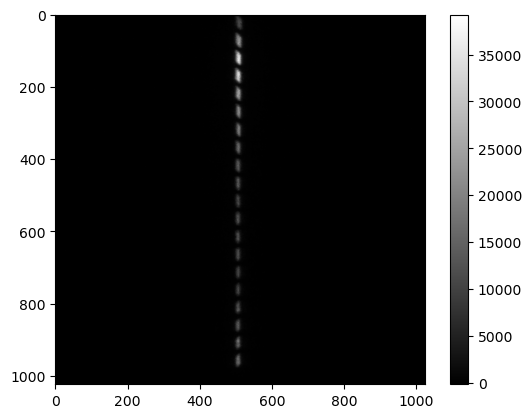

In [ ]:
shot=250424010
attrs = get_shot_attributes(OUT_H5, shot_id=shot)
img_data  = attrs["image"]
print(img_data.shape) 
print(attrs["dataset_attrs"]["Acceleration Voltage (kV)"])

plt.imshow(img_data, cmap='gray')
plt.colorbar()

In [ ]:
import h5py

with h5py.File(OUT_H5, "r") as f:
    print("Top-level keys:", list(f.keys()))
    if "shots" in f:
        keys = list(f["shots"].keys())
        print("Number of shots:", len(keys))
        print("First 20 shot keys:", keys[:20])
        print("Contains 250219017?", "250219017" in keys)
        # Also check legacy style
        print("Contains 250219_017?", "250219_017" in keys)
        print("Contains 250219_17?", "250219_17" in keys)

Top-level keys: ['meta', 'shots']
Number of shots: 384
First 20 shot keys: ['250219017', '250219018', '250219019', '250219020', '250219021', '250219022', '250219023', '250219024', '250219025', '250219026', '250416002', '250416003', '250416004', '250416005', '250416006', '250416007', '250423001', '250423002', '250423003', '250423004']
Contains 250219017? True
Contains 250219_017? False
Contains 250219_17? False


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Testing file: G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Calibration\250422\250422  020.spe
Shape: (1024, 1024)
Dtype: float32


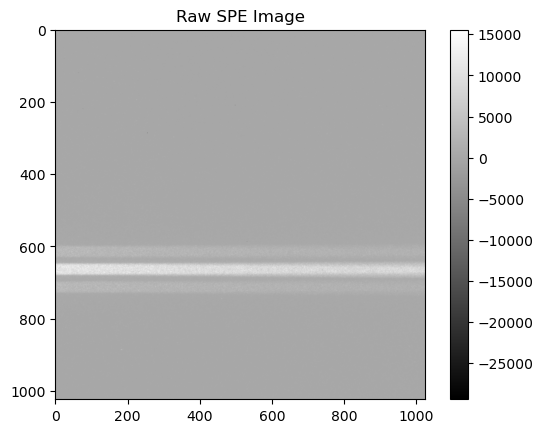

In [ ]:
%load_ext autoreload
%autoreload 2

from regions_processing import *

# test_file = os.path.join(CAL_FOLDER, f"{CAL_PREFIX}  007.spe")
test_file = r"G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Calibration\250422\250422  020.spe"

print("Testing file:", test_file)

img = load_spe_image(test_file)

print("Shape:", img.shape)
print("Dtype:", img.dtype)
# print("Min / Max:", img.min(), img.max())
# attrs = get_shot_attributes(OUT_H5, shot_id=250422015)
# gate_shot = attrs["dataset_attrs"]["Gate Width (ns)"]

plt.imshow(img, cmap='gray')
plt.title("Raw SPE Image")
plt.colorbar()
plt.show()

Found 29 SPE files


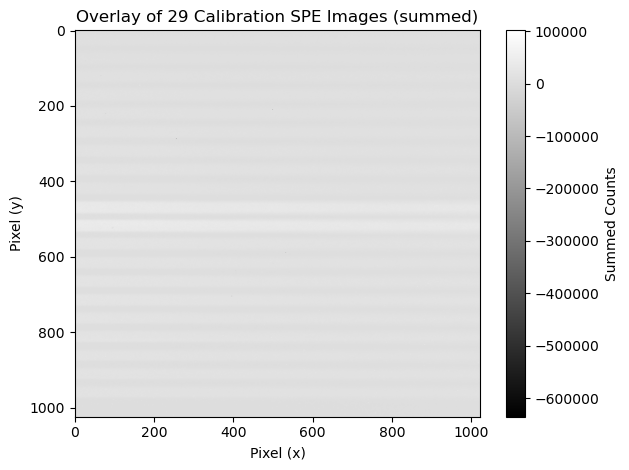

In [ ]:
from pathlib import Path

cal_folder = Path(r"G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Calibration\250422")
spe_files = sorted(cal_folder.glob("*.spe"))

print(f"Found {len(spe_files)} SPE files")

# Load all images and sum them into one overlay
stacked = None
for f in spe_files:
    img = load_spe_image(str(f))
    if stacked is None:
        stacked = img.astype(np.float64)
    else:
        stacked += img.astype(np.float64)

plt.figure()
plt.imshow(stacked, cmap='gray', aspect='auto')
plt.title(f"Overlay of {len(spe_files)} Calibration SPE Images (summed)")
plt.xlabel("Pixel (x)")
plt.ylabel("Pixel (y)")
plt.colorbar(label="Summed Counts")
plt.tight_layout()
plt.show()

c:\Users\elyse\Downloads\Python\Zap\spectroscopy\regions_processing.py:309: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = remove_small_objects(bw, min_size=min_area)


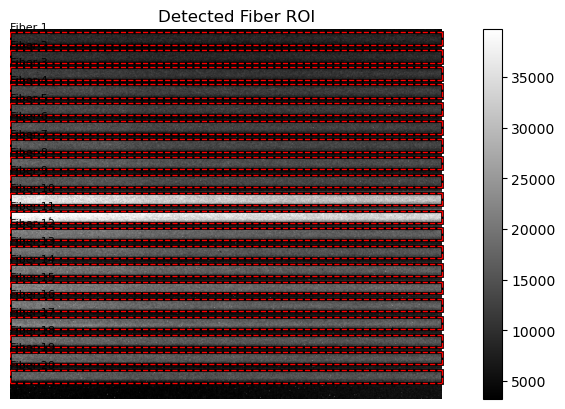

In [ ]:
fibers = extract_fiber_and_calibrate(
    stacked,
    lamp_csv_path=LAMP_CSV_PATH,
    sauvola_k=0.01,
    smooth_window=5)

if fibers is None:
    print("No region found.")
else:
    # for fiber in fibers:
    #     print("BBox:", fiber["bbox"])
    #     print("Centroid:", fiber["centroid_index"])
    #     print("Area:", fiber["area"])
    show_fiber_boxes(stacked, fibers, title="Detected Fiber ROI")

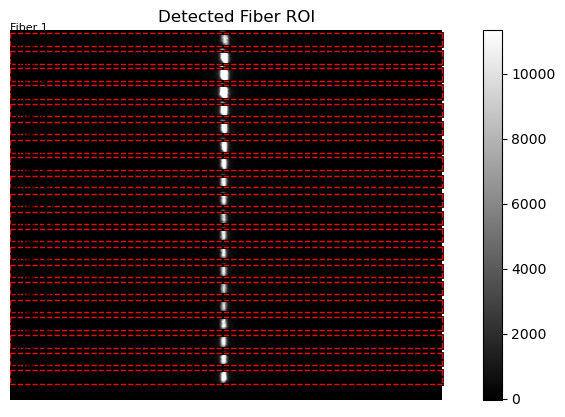

In [ ]:
show_fiber_boxes(img_data, fibers, title="Detected Fiber ROI")



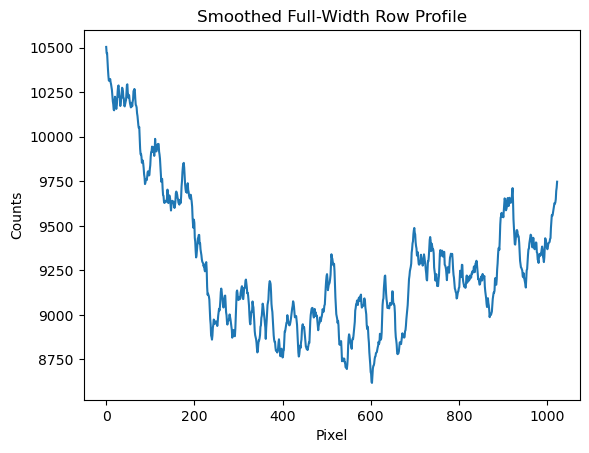

In [ ]:
row_profile = fibers[0]["row_profile_full"]

plt.plot(row_profile)
plt.title("Smoothed Full-Width Row Profile")
plt.xlabel("Pixel")
plt.ylabel("Counts")
plt.show()

Multiplier shape: (1024,)


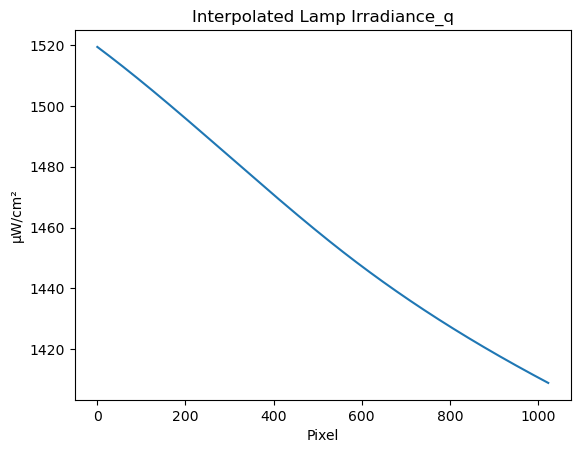

In [ ]:
irr_test = get_irradiance_multiplier(
    row_profile,
    lamp_csv_path=LAMP_CSV_PATH)

print("Multiplier shape:", irr_test["multiplier_uW_cm2_per_count"].shape)

plt.plot(irr_test["irradiance_q_uW_cm2"])
plt.title("Interpolated Lamp Irradiance_q")
plt.xlabel("Pixel")
plt.ylabel("µW/cm²")
plt.show()

[1035.7894631  2002.58845962 2349.39309896 1989.18155208 1448.12889032
 1096.23601189  918.39397355  737.80868216  702.17708924  270.95179767
  203.38138284  481.24632596  509.21371596  463.90965019  394.93720447
  425.68450169  525.3482235   600.25006241  679.47783473  785.08362169]


Text(0.5, 1.0, 'Calibrated Fiber Intensities')

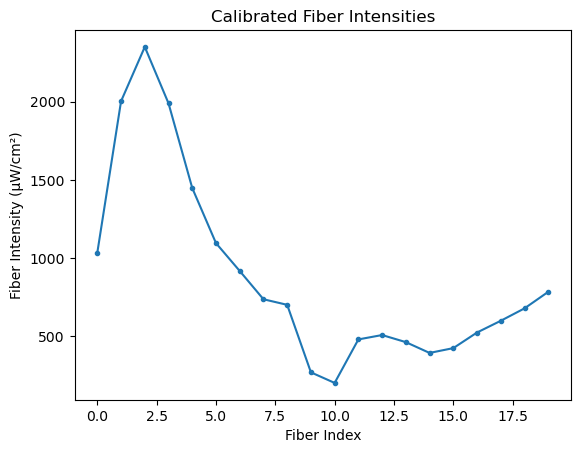

In [ ]:
real_result = extract_real_image_fiber_intensities(
    img=img_data,
    fibers=fibers,   # from your calibration-image extraction
    min_area=20,
    sauvola_window=31,
    sauvola_k=0.2,
    profile_half_height=3
)

fiber_intensities = real_result["fiber_intensities_uW_cm2"]
print(fiber_intensities)

plt.plot(fiber_intensities, marker='.')
plt.ylabel("Fiber Intensity (µW/cm²)")
plt.xlabel("Fiber Index")
plt.title("Calibrated Fiber Intensities")

Shot: 250219017
Gate width: 50.0 ns (5.000e-08 s)
160524021 linear density is 7069575688749126656: 
Converged in 454 iterations: gamma = 0.005460, Linear density = 7153614468239797248


c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:248: RuntimeWarning: divide by zero encountered in divide
  )
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:248: RuntimeWarning: invalid value encountered in multiply
  )
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:247: RuntimeWarning: divide by zero encountered in scalar divide
  linestyle='none',
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:254: RuntimeWarning: invalid value encountered in multiply
  


Converged in 453 iterations: gamma = 0.005470, Linear density = 7178138600768018432
Converged in 453 iterations: gamma = 0.005470, Linear density = 7178138600768018432
Using DHI/MDSplus-based SXB (per chord) with fallback: profile used for 4/20 chords
SXB const fallback = 118.9 ionizations/photon
SXB chords range  = [10.73, 118.9] ionizations/photon
[5.69758450e+30 4.93117201e+30 4.19912597e+29 3.43935392e+29
 3.08931858e+30 2.86617633e+30 3.36672981e+30 3.69551484e+30
 3.49254720e+30 1.47599897e+30]

Abel inversion (analysis_notebook params; 5 center-most chords) shell emissivities:
  chords used: 5
  shell[00] = 1.01678e+29
  shell[01] = 1.25863e+29
  shell[02] = 1.64461e+29
  shell[03] = 2.09011e+29
  shell[04] = 1.1605e+29
  inner_shell_emissivity = 1.1604990230654142e+29
  cond(L) = 3709.138634929967

Per-fiber results (first 5):
i= 0  x=-11.80 mm  Gamma=7.517e+30 atoms/m^2/s  m_dot=7.529e+04 mg/s
i= 1  x=-10.56 mm  Gamma=1.453e+31 atoms/m^2/s  m_dot=1.456e+05 mg/s
i= 2  x= -9.32 

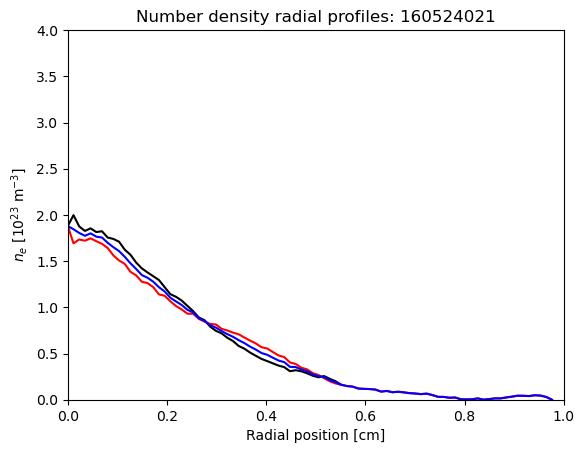

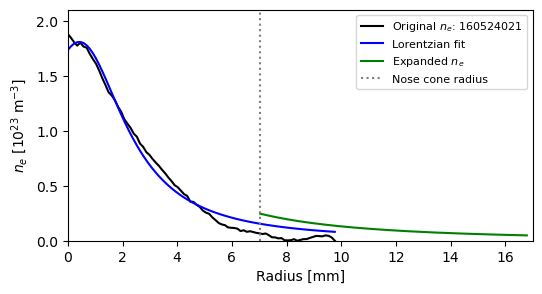

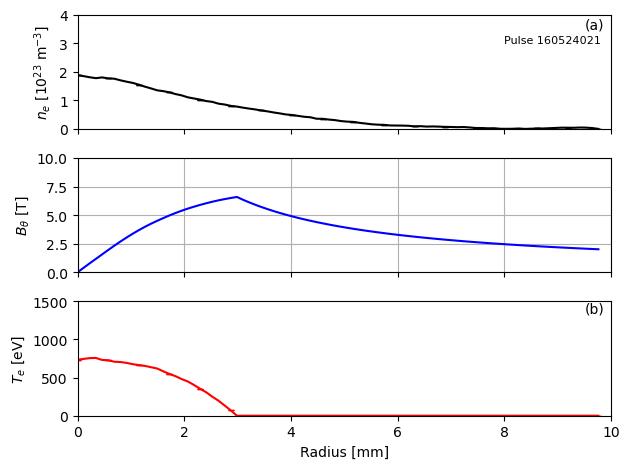

<Figure size 640x480 with 0 Axes>

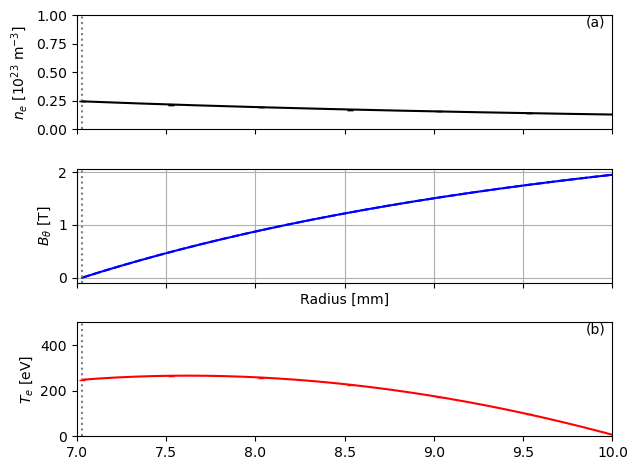

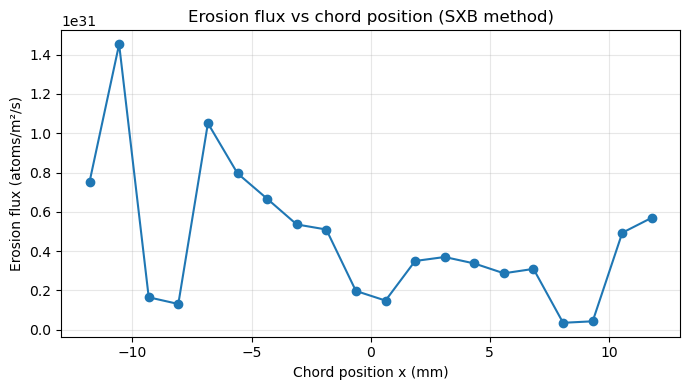

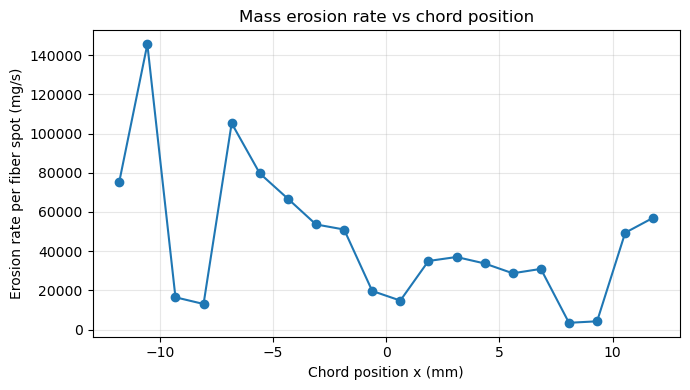

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from read_sxb_class import read_sxb

if "fiber_intensities" not in globals():
    raise NameError("Expected `fiber_intensities` from Cell 11 (fiber_intensities_uW_cm2).")

# Gate width from HDF5 attrs (ns -> s)
gate_ns = None
if "attrs" in globals():
    gate_ns = attrs.get("dataset_attrs", {}).get("Gate Width (ns)", None)
if gate_ns is None:
    gate_ns = attrs.get("dataset_attrs", {}).get("Gate Width", None) if "attrs" in globals() else None
if gate_ns is None:
    raise KeyError("Could not find Gate Width (ns) in `attrs['dataset_attrs']`. Re-run Cell 3 or provide gate_ns manually.")
gate_exp_s = float(gate_ns) * 1e-9
print(f"Gate width: {gate_ns} ns ({gate_exp_s:.3e} s)")

# Calibration exposure time used implicitly by the lamp-derived multiplier.
# This matches the PI-MAX4 max exposure used in `SXB_Analysis.py`.
gate_cal_s = 21.0

# Wavelength for C-III line used throughout the SXB pipeline
lambda_nm = 229.7
h = 6.62607015e-34
c = 299_792_458.0
E_ph = h * c / (lambda_nm * 1e-9)  # J/photon

# Carbon atom mass (mg) (matches `sxb_campaign.py`)
m_C_mg = 1.9926e-20

# Spot size on the nose cone (radius in meters) (matches `sxb_campaign.py` comment)
r_spot_m = 400e-6
A_spot_m2 = np.pi * r_spot_m**2

# ----------------------------
# Fiber index -> chord position mapping
# ----------------------------
fiber_idx = np.arange(len(fiber_intensities))
x_mm = np.linspace(-23.6 / 2, 23.6 / 2, len(fiber_intensities))  # signed chord position
r_mm = x_mm
r_m = 1e-3 * r_mm

# ----------------------------
# Irradiance -> photon flux
# ----------------------------
I_uW_cm2 = np.asarray(fiber_intensities, dtype=float)
I_W_m2_raw = I_uW_cm2 * 1e-6 * 1e4  # (µW/cm^2) -> (W/m^2)

# Correct for the calibration/shot exposure mismatch (counts scale ~ linearly with exposure).
# Without this, the multiplier effectively returns ~irradiance * (gate_exp/gate_cal).
gate_corr = gate_cal_s / gate_exp_s
I_W_m2 = I_W_m2_raw * gate_corr

photon_flux = I_W_m2 / E_ph  # photons / m^2 / s

# ----------------------------
# SXB coefficient -> erosion flux
# ----------------------------
# Default (constant) parameters used in SXB_Analysis.py
Te_eV = 1000.0
ne_m3 = 2e23

# Optional: use DHI/MDSplus profiles (same path as SXB_Analysis.py via `dhi_profiles`)
USE_DHI_PROFILE_SXB = True
DHI_RADIUS_M = 0.003  # meters; matches `read_dhi_mds.py` __main__ example

# Create an instance of the SXB coefficient reader
sxb_vals = read_sxb("C-III")

# Constant SXB (fallback)
sxb_const = float(sxb_vals.get_sxb(Te_eV, ne_m3))

sxb_chords = None
if USE_DHI_PROFILE_SXB:
    try:
        from read_dhi_mds import dhi_profiles

        # Returns: r (m), ne(r), Btheta(r), Te(r), and error arrays
        r_dhi, ne_dhi, _, te_dhi, *_ = dhi_profiles("lateral", radius=float(DHI_RADIUS_M))

        r_dhi = np.asarray(r_dhi, dtype=float)
        ne_dhi = np.asarray(ne_dhi, dtype=float)
        te_dhi = np.asarray(te_dhi, dtype=float)

        # Ensure monotonic increasing radius for interpolation
        order = np.argsort(r_dhi)
        r_dhi = r_dhi[order]
        ne_dhi = ne_dhi[order]
        te_dhi = te_dhi[order]

        # Chord positions (impact parameters) in meters
        chord_pos_m = np.abs(1e-3 * np.linspace(-23.6 / 2, 23.6 / 2, 20))

        # Interpolate ne and Te onto chord locations; out-of-range -> NaN
        ne_ch = np.interp(chord_pos_m, r_dhi, ne_dhi, left=np.nan, right=np.nan)
        te_ch = np.interp(chord_pos_m, r_dhi, te_dhi, left=np.nan, right=np.nan)

        # Compute chord-dependent SXB; fallback to constant when profile values are invalid
        sxb_chords = np.empty_like(chord_pos_m, dtype=float)
        used_profile = 0
        for i in range(chord_pos_m.size):
            te_i = float(te_ch[i])
            ne_i = float(ne_ch[i])
            if np.isfinite(te_i) and np.isfinite(ne_i) and te_i > 0 and ne_i > 0:
                sxb_chords[i] = float(sxb_vals.get_sxb(te_i, ne_i))
                used_profile += 1
            else:
                sxb_chords[i] = sxb_const

        print(
            f"Using DHI/MDSplus-based SXB (per chord) with fallback: "
            f"profile used for {used_profile}/20 chords"
        )
        print(f"SXB const fallback = {sxb_const:.4g} ionizations/photon")
        print(
            f"SXB chords range  = [{np.nanmin(sxb_chords):.4g}, {np.nanmax(sxb_chords):.4g}] ionizations/photon"
        )

    except Exception as e:
        print("DHI/MDSplus SXB failed; falling back to constant SXB. Error:", repr(e))
        sxb_chords = None

if sxb_chords is None:
    print(f"Using constant SXB(C-III) at Te={Te_eV:g} eV, ne={ne_m3:.3g} m^-3: {sxb_const:.4g} ionizations/photon")
    sxb_chords = np.full(20, sxb_const, dtype=float)

# Erosion flux: atoms / m^2 / s (vector, per chord)
erosion_flux_atoms_m2_s = 4.0 * np.pi * sxb_chords * photon_flux

DO_ABEL_INVERSION = True

# Abel inversion regularization parameters
ABEL_LAM = 1.0
ABEL_W_INNER = 1.0
ABEL_R_MM = 11.8
ABEL_ELEC_RAD_MM = 0.4
ABEL_N_SHELLS = 5

# Only use the 5 chords closest to the center *after* applying the same preprocessing
# as analysis_notebook (ascending_suffix + electrode crop)
ABEL_USE_N_CHORDS = 5

abel_eps = None
abel_diag = None
if DO_ABEL_INVERSION:
    from shot_processing import ascending_suffix, build_L_onion, tikhonov_inversion

    chord_vec = np.asarray(erosion_flux_atoms_m2_s, dtype=float)
    if chord_vec.size != 20:
        raise ValueError(f"Expected 20 chords, got {chord_vec.size}.")

    # Same half and ordering as analysis_notebook.ipynb
    b_raw = np.linspace(11.8, 0.0, 10)
    I_left = chord_vec[:10]  # center -> inner
    I_right = np.flip(chord_vec[10:])  # outer -> center
    print(I_right)
    # I_use = I_left
    I_use = I_right

    # Same preprocessing as analysis_notebook / prepare_and_peel
    b_keep, I_keep = ascending_suffix(b_raw, I_use, elec_rad=float(ABEL_ELEC_RAD_MM), inner_chord_num=0)

    if len(b_keep) < int(ABEL_USE_N_CHORDS):
        print(
            f"\nAbel inversion skipped: only {len(b_keep)} usable chord(s) after ascending_suffix/electrode crop "
            f"(need {ABEL_USE_N_CHORDS})."
        )
    else:
        # Use ONLY the N chords closest to center (smallest b), in outer->center order
        b_used = np.asarray(b_keep, float)[-int(ABEL_USE_N_CHORDS):]
        I_used = np.asarray(I_keep, float)[-int(ABEL_USE_N_CHORDS):]

        # 5 shells, matching analysis_notebook parameters
        edges = np.linspace(float(ABEL_R_MM), float(ABEL_ELEC_RAD_MM) - 0.4, int(ABEL_N_SHELLS) + 1)
        L = build_L_onion(b_used, edges, elec_rad=float(ABEL_ELEC_RAD_MM))

        try:
            eps_rec = tikhonov_inversion(L, I_used, lam=float(ABEL_LAM), w_inner=float(ABEL_W_INNER))
            abel_eps = np.asarray(eps_rec, dtype=float)
            abel_diag = {
                "b_used": np.asarray(b_used, dtype=float),
                "I_used": np.asarray(I_used, dtype=float),
                "L": np.asarray(L, dtype=float),
                "edges": np.asarray(edges, dtype=float),
            }

            print("\nAbel inversion (analysis_notebook params; 5 center-most chords) shell emissivities:")
            print(f"  chords used: {len(abel_diag['b_used'])}")
            for i, v in enumerate(abel_eps):
                print(f"  shell[{i:02d}] = {v:.6g}")
            print("  inner_shell_emissivity =", float(abel_eps[-1]))
            print("  cond(L) =", float(np.linalg.cond(abel_diag["L"])))

        except Exception as e:
            print("Abel inversion failed:", repr(e))

# ----------------------------
# Mass erosion rate per fiber spot
# ----------------------------
erosion_rate_mg_s = erosion_flux_atoms_m2_s * m_C_mg * A_spot_m2
mass_flux_mg_m2_s = erosion_flux_atoms_m2_s * m_C_mg

# ----------------------------
# Quick sanity outputs
# ----------------------------
print("\nPer-fiber results (first 5):")
for i in range(min(5, len(fiber_idx))):
    print(
        f"i={i:2d}  x={x_mm[i]:6.2f} mm  "
        f"Gamma={erosion_flux_atoms_m2_s[i]:.3e} atoms/m^2/s  "
        f"m_dot={erosion_rate_mg_s[i]:.3e} mg/s"
    )

print("\nTotals over all 20 fiber spots (sum of mg/s over spots):")
print("  sum(m_dot) =", float(np.nansum(erosion_rate_mg_s)), "mg/s")

# ----------------------------
# Plots
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(r_mm, erosion_flux_atoms_m2_s, "o-")
plt.xlabel("Chord position x (mm)")
plt.ylabel("Erosion flux (atoms/m²/s)")
plt.title("Erosion flux vs chord position (SXB method)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(r_mm, erosion_rate_mg_s, "o-")
plt.xlabel("Chord position x (mm)")
plt.ylabel("Erosion rate per fiber spot (mg/s)")
plt.title("Mass erosion rate vs chord position")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from shot_processing import tikhonov_inversion

if "abel_diag" not in globals() or abel_diag is None:
    raise NameError("Run Cell 12 first to populate `abel_diag`.")

L = np.asarray(abel_diag["L"], dtype=float)
I_used = np.asarray(abel_diag["I_used"], dtype=float)

target_inner = 1e29
lams = np.logspace(-6, 6, 25)  # very wide sweep
w_inners = np.concatenate(([0.0], np.logspace(-6, 6, 13)))

best_any = None
best_nozero = None
for lam in lams:
    for w_inner in w_inners:
        eps = tikhonov_inversion(L, I_used, lam=float(lam), w_inner=float(w_inner))
        eps = np.asarray(eps, dtype=float)
        zthr = 1e-12 * (np.nanmax(eps) if np.nanmax(eps) > 0 else 1.0)
        zeros = int(np.sum(eps <= zthr))
        inner = float(eps[-1])
        inner_log_err = abs(np.log10(max(inner, 1e-300)) - 29.0)
        score = 10.0 * zeros + inner_log_err
        row = (score, zeros, float(lam), float(w_inner), inner, eps)
        if best_any is None or score < best_any[0]:
            best_any = row
        if zeros == 0:
            if best_nozero is None or score < best_nozero[0]:
                best_nozero = row

print("Best overall (may have zeros):")
score, zeros, lam, w_inner, inner, eps = best_any
print(f"score={score:.3f}  zeros={zeros}  lam={lam:.3e}  w_inner={w_inner:.3e}  inner={inner:.3e}")
print("eps =", eps)

if best_nozero is None:
    print("\nNo (lam, w_inner) in this sweep produced all 5 shells > 0 under NNLS.")
else:
    print("\nBest with no zero shells:")
    score, zeros, lam, w_inner, inner, eps = best_nozero
    print(f"score={score:.3f}  zeros={zeros}  lam={lam:.3e}  w_inner={w_inner:.3e}  inner={inner:.3e}")
    print("eps =", eps)

Best overall (may have zeros):
score=3.109  zeros=0  lam=1.000e+02  w_inner=0.000e+00  inner=7.779e+25
eps = [7.12886255e+27 4.41868108e+27 2.09845363e+27 8.26545932e+26
 7.77876036e+25]

Best with no zero shells:
score=3.109  zeros=0  lam=1.000e+02  w_inner=0.000e+00  inner=7.779e+25
eps = [7.12886255e+27 4.41868108e+27 2.09845363e+27 8.26545932e+26
 7.77876036e+25]
